# Full-cohort feature extraction: band power

**Objective:** Extract features (band power, PLI, and future families) across
the full validated cohort, using orchestration validated in
`06_feature_extraction_pilot.ipynb`. Assemble into a single feature matrix
per session and save for the modelling phase.

**Inputs:** `data/derivatives_heog_off/<subject_id>/sub-*_restEC-epo.fif` —
restEC condition, heog_off variant (primary per Decision 1).

**Progress:**
- [x] Band power (160/160, 0 failures)
- [x] PLI
- [ ] Coherence, PLV
- [ ] Kuramoto

In [1]:
# Imports and setup
import sys
import numpy as np
import pandas as pd
from pathlib import Path
import mne
import glob
import pyarrow
mne.set_log_level('WARNING')

# Temporary bootstrap path, just to make src/ importable — not the real project root
sys.path.insert(0, str(Path.cwd().parent))

from src.preprocessing import find_repo_root
project_root = find_repo_root()
data_dir = project_root / "data"

from src.features import extract_subject_features

print(f"Project root: {project_root}")
print(f"Data dir: {data_dir}")

Project root: /Users/romyweinstock/eeg-rtms-response-prediction
Data dir: /Users/romyweinstock/eeg-rtms-response-prediction/data


In [2]:
# Build the path to the derivatives_heog_off folder
derivatives_heog_off_path = data_dir / "derivatives_heog_off"

# Find every restEC epochs file, searching recursively since
sub_epoch_list = list(derivatives_heog_off_path.rglob("sub-*_restEC-epo.fif"))

# Check matches 
print(len(sub_epoch_list))
print(sub_epoch_list[0])

# Pull the subject ID out of each match
ID_list = []
for sub in sub_epoch_list:
    ID_list.append(sub.stem.split("_")[0])
assert len(ID_list) == 160, f"expected 160 rows got {len(ID_list)}"

160
/Users/romyweinstock/eeg-rtms-response-prediction/data/derivatives_heog_off/sub-88045809/sub-88045809_restEC-epo.fif


In [3]:
# Loop extract_subject_features across the full cohort
condition = "restEC"
variant = "heog_off"

qc_log = pd.read_csv(data_dir / 'batch_results_log_full_cohort.csv')

bands = {
    "delta": (2, 4),
    "theta": (4, 8),
    "alpha": (8, 13),
    "beta": (13, 30),
    "gamma": (30, 45),
}

results_list = []
for subject_id in ID_list:
    result = extract_subject_features(subject_id, condition, variant, data_dir, qc_log, bands)
    results_list.append(result)

print(f"Processed {len(results_list)} subjects")

n_failed = sum(1 for r in results_list if r["reason"] != "ok")
print(f"Failures: {n_failed}")

/Users/romyweinstock/eeg-rtms-response-prediction/src/features.py:109: RuntimeWarning: There were no Annotations stored in <EpochsFIF | 21 events (all good), 0 – 4.998 s (baseline off), ~12.5 MiB, data loaded,
 '1': 21>, so metadata was not modified.
  con = spectral_connectivity_epochs(
/Users/romyweinstock/eeg-rtms-response-prediction/src/features.py:149: RuntimeWarning: There were no Annotations stored in <EpochsFIF | 21 events (all good), 0 – 4.998 s (baseline off), ~12.5 MiB, data loaded,
 '1': 21>, so metadata was not modified.
  con_multi = spectral_connectivity_epochs(
/Users/romyweinstock/eeg-rtms-response-prediction/src/features.py:109: RuntimeWarning: There were no Annotations stored in <EpochsFIF | 23 events (all good), 0 – 4.998 s (baseline off), ~13.6 MiB, data loaded,
 '1': 23>, so metadata was not modified.
  con = spectral_connectivity_epochs(
/Users/romyweinstock/eeg-rtms-response-prediction/src/features.py:149: RuntimeWarning: There were no Annotations stored in <Epo

Processed 160 subjects
Failures: 0


In [4]:
# Assemble into one dataframe
bandpower_full_cohort_df = pd.DataFrame(results_list)
print(bandpower_full_cohort_df.shape)
print(bandpower_full_cohort_df.columns.tolist())

(160, 5031)
['subject_id', 'condition', 'variant', 'reason', 'heog_variant', 'preprocessing_status', 'n_epochs_before', 'n_epochs_after', 'output_path', 'autoreject_consensus', 'autoreject_n_interpolate', 'autoreject_extreme', 'heog_n_candidates', 'heog_n_valid', 'heog_correction_applied', 'preprocessing_error', 'Fp1_delta_power', 'Fp2_delta_power', 'F7_delta_power', 'F3_delta_power', 'Fz_delta_power', 'F4_delta_power', 'F8_delta_power', 'FC3_delta_power', 'FCz_delta_power', 'FC4_delta_power', 'T7_delta_power', 'C3_delta_power', 'Cz_delta_power', 'C4_delta_power', 'T8_delta_power', 'CP3_delta_power', 'CPz_delta_power', 'CP4_delta_power', 'P7_delta_power', 'P3_delta_power', 'Pz_delta_power', 'P4_delta_power', 'P8_delta_power', 'O1_delta_power', 'Oz_delta_power', 'O2_delta_power', 'Fp1_theta_power', 'Fp2_theta_power', 'F7_theta_power', 'F3_theta_power', 'Fz_theta_power', 'F4_theta_power', 'F8_theta_power', 'FC3_theta_power', 'FCz_theta_power', 'FC4_theta_power', 'T7_theta_power', 'C3_the

In [5]:
# Missingness check across the full feature matrix
total_missing = bandpower_full_cohort_df.isna().sum().sum()
print(f"Total missing values: {total_missing}")

# If any missingness exists, break it down by column 
if total_missing > 0:
    missing_by_col = bandpower_full_cohort_df.isna().sum()
    print(missing_by_col[missing_by_col > 0])

Total missing values: 160
preprocessing_error    160
dtype: int64


In [6]:
# Confirm preprocessing_status is consistently non-null, supporting the
# interpretation that preprocessing_error is NaN because nothing failed
print(bandpower_full_cohort_df['preprocessing_status'].value_counts(dropna=False))

preprocessing_status
ok    160
Name: count, dtype: int64


**Missingness check**. preprocessing_error is NaN for all 160 subjects (160/160 missing)- expected, not a data quality issue. preprocessing_status confirms all 160 subjects preprocessed successfully ("ok"), and preprocessing_error is only ever populated on a preprocessing failure. No other columns show any missingness. Combined with reason == "ok" for all 160 rows (feature-extraction stage), both pipeline stages independently confirm a clean run.

In [7]:
# Per-subject check: does posterior alpha exceed frontal alpha for each subject
posterior_channels = ['O1', 'O2', 'Pz']
frontal_channels = ['Fp1', 'Fp2']

posterior_alpha = bandpower_full_cohort_df[[f"{ch}_alpha_power" for ch in posterior_channels]].mean(axis=1)
frontal_alpha = bandpower_full_cohort_df[[f"{ch}_alpha_power" for ch in frontal_channels]].mean(axis=1)

posterior_exceeds_frontal = posterior_alpha > frontal_alpha

n_subjects_matching = posterior_exceeds_frontal.sum()
pct_subjects_matching = posterior_exceeds_frontal.mean() * 100

print(f"{n_subjects_matching}/160 subjects show posterior > frontal alpha ({pct_subjects_matching:.1f}%)")

143/160 subjects show posterior > frontal alpha (89.4%)


In [8]:
# Do the non-matching subjects cluster with existing QC flags, or are they
# scattered independent of preprocessing quality?
non_matching = bandpower_full_cohort_df[~posterior_exceeds_frontal]

print(non_matching[['subject_id', 'n_epochs_after', 'autoreject_extreme', 'autoreject_consensus']])
print()
print("n_epochs_after — non-matching subjects:")
print(non_matching['n_epochs_after'].describe())
print("n_epochs_after — full cohort:")
print(bandpower_full_cohort_df['n_epochs_after'].describe())

       subject_id  n_epochs_after  autoreject_extreme  autoreject_consensus
10   sub-88059261            22.0               False                   0.2
30   sub-88059573            24.0                True                   1.0
31   sub-88066953            23.0               False                   0.2
34   sub-88012817            24.0                True                   1.0
39   sub-88020381            23.0               False                   0.1
45   sub-88012053            24.0                True                   1.0
47   sub-88061597            23.0               False                   0.2
48   sub-88043065            24.0                True                   1.0
50   sub-88025685            23.0               False                   0.2
53   sub-88023529            23.0               False                   0.2
69   sub-88052869            23.0               False                   0.2
75   sub-88044501            21.0               False                   0.5
86   sub-880

**Distribution check - posterior vs. frontal alpha, full cohort.** 143/160 subjects (89.4%) show posterior alpha (mean of O1, O2, Pz) exceeding frontal alpha (mean of Fp1, Fp2), consistent with the pilot subject and expected resting-EEG topography. The 17 non-matching subjects were checked against existing QC flags: their n_epochs_after (21-24, mean 23.1) falls within the full cohort's established range, and their autoreject_extreme rate (41%) is close to the cohort-wide baseline (~38%), showing no meaningful clustering on either measure. This suggests the non-matching subjects reflect genuine inter-subject variability rather than a QC-driven artifact, though this rules out only the two QC dimensions checked here, not every possible explanation.

In [9]:
# Save as Parquet file as it stores the dtype schema alongside the data
features_dir = data_dir / "features"
features_dir.mkdir(parents=True, exist_ok=True)

bandpower_full_cohort_df.to_parquet(features_dir / "bandpower_full_cohort.parquet")

In [10]:
reload_check = pd.read_parquet(features_dir / "bandpower_full_cohort.parquet")
print(reload_check.shape == bandpower_full_cohort_df.shape)
print(reload_check.equals(bandpower_full_cohort_df))

True
True


## Full-cohort band power extraction summary 

**Objective**: Extract band power features (5 bands × 26 channels) across the full validated cohort using the pilot-validated orchestrator (06), assemble into one feature matrix, QC it, and save.

**Result**: 160/160 subjects processed successfully (0 extraction failures). Assembled into a 160×146 dataframe (130 feature columns + 4 identity/status + 12 QC columns). Saved as data/features/bandpower_full_cohort.parquet, reload-verified for exact shape and value equality.

**QC findings**:

Missingness: only preprocessing_error is null (160/160), expected - populated only on preprocessing failure, and preprocessing_status confirms all 160 succeeded.
Distribution: 143/160 subjects (89.4%) show posterior alpha > frontal alpha, consistent with the pilot subject and expected resting-EEG topography. The 17 non-matching subjects show no meaningful clustering on n_epochs_after or autoreject_extreme relative to the cohort baseline, suggesting genuine inter-subject variability rather than a QC artifact (checked on these two dimensions only, not exhaustive).

## Full-cohort PLI extraction

**Objective**: Extend the full-cohort run to include PLI, using extract_subject_features (now updated to call compute_pli alongside compute_band_power, validated in 06_feature_extraction_pilot.ipynb on the pilot subject and a 6-subject batch). Reruns extraction across all 160 subjects, assembles into one matrix containing both feature families, QCs, and saves.

Inputs: Same as above - data/derivatives_heog_off/<subject_id>/sub-*_restEC-epo.fif, restEC condition, heog_off variant.

Assumptions: ID_list, condition, variant, data_dir, qc_log, and bands are reused from the band power section above, not rebuilt. PLI adds 1,625 columns (325 upper-triangle channel pairs x 5 bands) to the existing 146-column band power matrix.

In [11]:
# Re-run extraction across the full cohort, now including PLI
results_list = []
for subject_id in ID_list:
    result = extract_subject_features(subject_id, condition, variant, data_dir, qc_log, bands)
    results_list.append(result)

print(f"Processed {len(results_list)} subjects")

n_failed = sum(1 for r in results_list if r["reason"] != "ok")
print(f"Failures: {n_failed}")

/Users/romyweinstock/eeg-rtms-response-prediction/src/features.py:109: RuntimeWarning: There were no Annotations stored in <EpochsFIF | 21 events (all good), 0 – 4.998 s (baseline off), ~12.5 MiB, data loaded,
 '1': 21>, so metadata was not modified.
  con = spectral_connectivity_epochs(
/Users/romyweinstock/eeg-rtms-response-prediction/src/features.py:149: RuntimeWarning: There were no Annotations stored in <EpochsFIF | 21 events (all good), 0 – 4.998 s (baseline off), ~12.5 MiB, data loaded,
 '1': 21>, so metadata was not modified.
  con_multi = spectral_connectivity_epochs(
/Users/romyweinstock/eeg-rtms-response-prediction/src/features.py:109: RuntimeWarning: There were no Annotations stored in <EpochsFIF | 23 events (all good), 0 – 4.998 s (baseline off), ~13.6 MiB, data loaded,
 '1': 23>, so metadata was not modified.
  con = spectral_connectivity_epochs(
/Users/romyweinstock/eeg-rtms-response-prediction/src/features.py:149: RuntimeWarning: There were no Annotations stored in <Epo

Processed 160 subjects
Failures: 0


In [12]:
# Assemble into one dataframe
full_cohort_features_df = pd.DataFrame(results_list)
print(full_cohort_features_df.shape)

(160, 5031)


In [13]:
# Missingness check across the full feature matrix
total_missing = full_cohort_features_df.isna().sum().sum()
print(f"Total missing values: {total_missing}")

if total_missing > 0:
    missing_by_col = full_cohort_features_df.isna().sum()
    print(missing_by_col[missing_by_col > 0])

Total missing values: 160
preprocessing_error    160
dtype: int64


In [14]:
# PLI-specific range check across the full cohort
pli_cols = [c for c in full_cohort_features_df.columns if c.endswith('_pli')]
print(f"PLI columns: {len(pli_cols)}")  # expect 1625

pli_values = full_cohort_features_df[pli_cols].values
print("Any NaNs:", pd.isna(pli_values).any())
print("Any out of [0,1]:", ((pli_values < 0) | (pli_values > 1)).any())

PLI columns: 1625
Any NaNs: False
Any out of [0,1]: False


## Full-cohort PLI extraction summary

**PLI extraction validated across the full cohort** (160/160 subjects, restEC, heog_off), using extract_subject_features updated to call compute_pli alongside compute_band_power.

**Result**: 160/160 subjects processed successfully (0 extraction failures). Assembled into a 160×1771 dataframe (146 band power/QC/identity columns + 1,625 PLI columns: 325 upper-triangle channel pairs x 5 bands).

### QC findings:

**Missingness**: identical pattern to band power - only preprocessing_error is null (160/160), expected, since it's populated only on a preprocessing failure and all 160 subjects preprocessed successfully. No missingness introduced by PLI or by assembly.
Range: all 1,625 PLI columns confirmed within [0,1] across all 160 subjects, no NaNs - consistent with the per-subject [0,1]/NaN assertions already enforced inside compute_pli itself, confirming nothing drifted during full-cohort assembly.

In [15]:
#Save to new file 
full_cohort_features_df.to_parquet(features_dir / "full_cohort_features.parquet")

In [16]:
reload_check = pd.read_parquet(features_dir / "full_cohort_features.parquet")
print(reload_check.shape == full_cohort_features_df.shape)
print(reload_check.equals(full_cohort_features_df))

True
True


## Full-cohort PLV, coherence extraction

**Objective**: Extend the full-cohort run to include PLv and coherence, using extract_subject_features. Reruns extraction across all 160 subjects, assembles into one matrix containing both feature families, QCs, and saves.

Inputs: Same as above - data/derivatives_heog_off/<subject_id>/sub-*_restEC-epo.fif, restEC condition, heog_off variant.

In [17]:
# Confirm the current kernel's extract_subject_features
# actually includes coherence/PLV before committing to the full 160-subject run
test_result = extract_subject_features(ID_list[0], condition, variant, data_dir, qc_log, bands)

coh_keys = [k for k in test_result if k.endswith('_coh')]
plv_keys = [k for k in test_result if k.endswith('_plv')]

print(f"Total keys: {len(test_result)}")   # expect 5021
print(f"Coh keys: {len(coh_keys)}")        # expect 1625
print(f"PLV keys: {len(plv_keys)}")        # expect 1625

/Users/romyweinstock/eeg-rtms-response-prediction/src/features.py:109: RuntimeWarning: There were no Annotations stored in <EpochsFIF | 21 events (all good), 0 – 4.998 s (baseline off), ~12.5 MiB, data loaded,
 '1': 21>, so metadata was not modified.
  con = spectral_connectivity_epochs(
/Users/romyweinstock/eeg-rtms-response-prediction/src/features.py:149: RuntimeWarning: There were no Annotations stored in <EpochsFIF | 21 events (all good), 0 – 4.998 s (baseline off), ~12.5 MiB, data loaded,
 '1': 21>, so metadata was not modified.
  con_multi = spectral_connectivity_epochs(


Total keys: 5031
Coh keys: 1625
PLV keys: 1625


In [18]:
# Re-run extraction across the full cohort, now including PLV and coherence

results_list = []
for subject_id in ID_list:
    result = extract_subject_features(subject_id, condition, variant, data_dir, qc_log, bands)
    results_list.append(result)

print(f"Processed {len(results_list)} subjects")

n_failed = sum(1 for r in results_list if r["reason"] != "ok")
print(f"Failures: {n_failed}")

/Users/romyweinstock/eeg-rtms-response-prediction/src/features.py:109: RuntimeWarning: There were no Annotations stored in <EpochsFIF | 21 events (all good), 0 – 4.998 s (baseline off), ~12.5 MiB, data loaded,
 '1': 21>, so metadata was not modified.
  con = spectral_connectivity_epochs(
/Users/romyweinstock/eeg-rtms-response-prediction/src/features.py:149: RuntimeWarning: There were no Annotations stored in <EpochsFIF | 21 events (all good), 0 – 4.998 s (baseline off), ~12.5 MiB, data loaded,
 '1': 21>, so metadata was not modified.
  con_multi = spectral_connectivity_epochs(
/Users/romyweinstock/eeg-rtms-response-prediction/src/features.py:109: RuntimeWarning: There were no Annotations stored in <EpochsFIF | 23 events (all good), 0 – 4.998 s (baseline off), ~13.6 MiB, data loaded,
 '1': 23>, so metadata was not modified.
  con = spectral_connectivity_epochs(
/Users/romyweinstock/eeg-rtms-response-prediction/src/features.py:149: RuntimeWarning: There were no Annotations stored in <Epo

Processed 160 subjects
Failures: 0


In [19]:
# Assemble into one dataframe
full_cohort_features_df = pd.DataFrame(results_list)
print(full_cohort_features_df.shape)
# Missingness check across the full feature matrix
total_missing = full_cohort_features_df.isna().sum().sum()
print(f"Total missing values: {total_missing}")

if total_missing > 0:
    missing_by_col = full_cohort_features_df.isna().sum()
    print(missing_by_col[missing_by_col > 0])

(160, 5031)
Total missing values: 160
preprocessing_error    160
dtype: int64


In [20]:

# PLV, coherence - specific range check across the full cohort
plv_cols = [c for c in full_cohort_features_df.columns if c.endswith('_plv')]
print(f"PLV columns: {len(plv_cols)}")  # expect 1625
coherence_cols = [c for c in full_cohort_features_df.columns if c.endswith('_coh')]
print(f"Coherence columns: {len(coherence_cols)}")  # expect 1625


plv_values = full_cohort_features_df[plv_cols].values
print("Any NaNs:", pd.isna(plv_values).any())
print("Any out of [0,1]:", ((plv_values < 0) | (plv_values > 1)).any())

coherence_values = full_cohort_features_df[coherence_cols].values
print("Any NaNs:", pd.isna(coherence_values).any())
print("Any out of [0,1]:", ((coherence_values < 0) | (coherence_values > 1)).any())

PLV columns: 1625
Coherence columns: 1625
Any NaNs: False
Any out of [0,1]: False
Any NaNs: False
Any out of [0,1]: False


In [21]:
#Save updated file 
full_cohort_features_df.to_parquet(features_dir / "full_cohort_features.parquet")
reload_check = pd.read_parquet(features_dir / "full_cohort_features.parquet")
print(reload_check.shape == full_cohort_features_df.shape)
print(reload_check.equals(full_cohort_features_df))

True
True


## Full-cohort Kuramoto extraction

**Objective**: Extend the full-cohort run to include kuramoto order parameter and metastabillity, using extract_subject_features. Reruns extraction across all 160 subjects, assembles into one matrix containing both feature families, QCs, and saves.

Inputs: Same as above - data/derivatives_heog_off/<subject_id>/sub-*_restEC-epo.fif, restEC condition, heog_off variant.

In [22]:
# Re-run extraction across the full cohort, now including Kuramoto

import time

results_list = []
start = time.time()
for subject_id in ID_list:
    result = extract_subject_features(subject_id, condition, variant, data_dir, qc_log, bands)
    results_list.append(result)
elapsed = time.time() - start

print(f"Processed {len(results_list)} subjects in {elapsed:.1f}s")

n_failed = sum(1 for r in results_list if r["reason"] != "ok")
print(f"Failures: {n_failed}")

/Users/romyweinstock/eeg-rtms-response-prediction/src/features.py:109: RuntimeWarning: There were no Annotations stored in <EpochsFIF | 21 events (all good), 0 – 4.998 s (baseline off), ~12.5 MiB, data loaded,
 '1': 21>, so metadata was not modified.
  con = spectral_connectivity_epochs(
/Users/romyweinstock/eeg-rtms-response-prediction/src/features.py:149: RuntimeWarning: There were no Annotations stored in <EpochsFIF | 21 events (all good), 0 – 4.998 s (baseline off), ~12.5 MiB, data loaded,
 '1': 21>, so metadata was not modified.
  con_multi = spectral_connectivity_epochs(
/Users/romyweinstock/eeg-rtms-response-prediction/src/features.py:109: RuntimeWarning: There were no Annotations stored in <EpochsFIF | 23 events (all good), 0 – 4.998 s (baseline off), ~13.6 MiB, data loaded,
 '1': 23>, so metadata was not modified.
  con = spectral_connectivity_epochs(
/Users/romyweinstock/eeg-rtms-response-prediction/src/features.py:149: RuntimeWarning: There were no Annotations stored in <Epo

Processed 160 subjects in 183.6s
Failures: 0


In [23]:
# Assemble into one dataframe
full_cohort_features_df = pd.DataFrame(results_list)
print(full_cohort_features_df.shape)  # expect (160, 5031)

# Missingness check across the full feature matrix
total_missing = full_cohort_features_df.isna().sum().sum()
print(f"Total missing values: {total_missing}")

if total_missing > 0:
    missing_by_col = full_cohort_features_df.isna().sum()
    print(missing_by_col[missing_by_col > 0])

# Cross-check failure count against preprocessing_status
print(full_cohort_features_df['preprocessing_status'].value_counts(dropna=False))

(160, 5031)
Total missing values: 160
preprocessing_error    160
dtype: int64
preprocessing_status
ok    160
Name: count, dtype: int64


In [24]:
# Kuramoto-specific range check across the full cohort
order_cols = [c for c in full_cohort_features_df.columns if c.endswith('_order')]
metastability_cols = [c for c in full_cohort_features_df.columns if c.endswith('_metastability')]
print(f"Order columns: {len(order_cols)}")          # expect 5
print(f"Metastability columns: {len(metastability_cols)}")  # expect 5

order_values = full_cohort_features_df[order_cols].values
print("Order - Any NaNs:", pd.isna(order_values).any())
print("Order - Any out of [0,1]:", ((order_values < 0) | (order_values > 1)).any())

metastability_values = full_cohort_features_df[metastability_cols].values
print("Metastability - Any NaNs:", pd.isna(metastability_values).any())
print("Metastability - Any negative:", (metastability_values < 0).any())

Order columns: 5
Metastability columns: 5
Order - Any NaNs: False
Order - Any out of [0,1]: False
Metastability - Any NaNs: False
Metastability - Any negative: False


In [25]:
# Save and reload-verify
full_cohort_features_df.to_parquet(features_dir / "full_cohort_features.parquet")

reload_check = pd.read_parquet(features_dir / "full_cohort_features.parquet")
print(reload_check.shape == full_cohort_features_df.shape)
print(reload_check.equals(full_cohort_features_df))

True
True


## IAF-proximity extraction (protocol-1 only)

**Objective**: Extract IAF and IAF-prox for the n=42 protocol-1 subgroup only, using compute_iaf directly (not extract_subject_features - see notebook 06 discussion). Assembles into a standalone matrix, QCs, and saves separately from full_cohort_features.parquet.

Inputs: data/derivatives_heog_off/<subject_id>/sub-*_restEC-epo.fif, restEC condition, heog_off variant, F3 channel, 7-13 Hz alpha window - restricted to the 42 subjects with rTMS PROTOCOL == 1.0 in cohort_filtered_n163.xlsx (TDBRAIN_ID column).

In [29]:
# IAF-proximity extraction, protocol-1 subjects only (n=42) - standalone,
# not integrated into extract_subject_features (see notebook 06 discussion)

cohort_df = pd.read_excel(data_dir / "cohort_filtered_n163.xlsx")
protocol_1_ids = cohort_df[cohort_df['rTMS PROTOCOL'] == 1.0]['TDBRAIN_ID'].tolist()

from src.features import load_subject_epochs, compute_iaf

iaf_results_list = []
for subject_id in protocol_1_ids:
    try:
        ep = load_subject_epochs(subject_id, condition, variant, data_dir)
        result = compute_iaf(ep, alpha_window=(7, 13), channel='F3')
        result["subject_id"] = subject_id
        result["reason"] = "ok"
    except Exception as e:
        result = {"subject_id": subject_id, "reason": str(e)}
    iaf_results_list.append(result)

iaf_df = pd.DataFrame(iaf_results_list)
print(iaf_df.shape)  # expect (42, 4): subject_id, iaf, iaf_prox, reason

n_failed = (iaf_df["reason"] != "ok").sum()
print(f"Failures: {n_failed}")

(42, 4)
Failures: 0


Any NaNs: False
IAF range: 7.080078125 - 11.23046875
IAF within [7,13]: True
count    42.000000
mean      1.176293
std       0.901377
min       0.009766
25%       0.483398
50%       0.966797
75%       1.943359
max       2.919922
Name: iaf_prox, dtype: float64


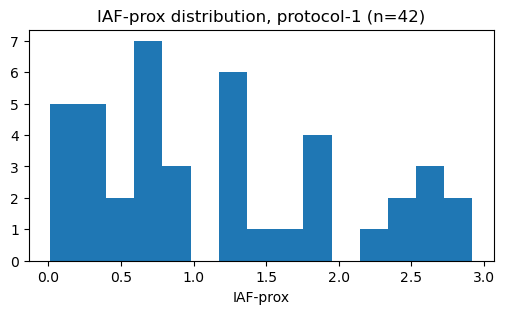

In [31]:
# QC: no NaNs, IAF within search window, sanity check on IAF-prox distribution
import matplotlib.pyplot as plt

print("Any NaNs:", iaf_df[["iaf", "iaf_prox"]].isna().any().any())
print("IAF range:", iaf_df["iaf"].min(), "-", iaf_df["iaf"].max())
print("IAF within [7,13]:", ((iaf_df["iaf"] >= 7) & (iaf_df["iaf"] <= 13)).all())

print(iaf_df["iaf_prox"].describe())

plt.figure(figsize=(6, 3))
plt.hist(iaf_df["iaf_prox"], bins=15)
plt.xlabel("IAF-prox")
plt.title("IAF-prox distribution, protocol-1 (n=42)")
plt.show()

In [32]:
# Save and reload-verify
iaf_df.to_parquet(features_dir / "iaf_protocol1.parquet")

reload_check = pd.read_parquet(features_dir / "iaf_protocol1.parquet")
print(reload_check.shape == iaf_df.shape)
print(reload_check.equals(iaf_df))

True
True


## Quality check for the full feature matrix
Checking for:
1. Row-wise missingness
2. Per-family summary stats side by side, to see the scale mismatch explicitly
3. Per-column variance scan across all 5031 columns, flagging near-zero-variance columns

In [58]:
full_df = pd.read_parquet(features_dir / "full_cohort_features.parquet")
#Check for missingness - expect 1 per row (preprocessing_error)
print(full_df.isna().sum(axis=1))
missing_per_row = full_df.isna().sum(axis=1)
print(missing_per_row.unique())  # confirm it really is 1 for every row, not just the ones shown

# which column is the NaN in, for a given row?
row0_missing_cols = full_df.columns[full_df.iloc[0].isna()]
print(row0_missing_cols)


0      1
1      1
2      1
3      1
4      1
      ..
155    1
156    1
157    1
158    1
159    1
Length: 160, dtype: int64
[1]
Index(['preprocessing_error'], dtype='str')


In [59]:
# Define an explicit QC & feature-columns lists 
id_qc_cols = [
    'subject_id', 'condition', 'variant', 'reason', 'heog_variant',
    'preprocessing_status', 'n_epochs_before', 'n_epochs_after',
    'output_path', 'autoreject_consensus', 'autoreject_n_interpolate',
    'autoreject_extreme', 'heog_n_candidates', 'heog_n_valid',
    'heog_correction_applied', 'preprocessing_error',
]

feature_cols = [c for c in full_df.columns if c not in id_qc_cols]
print(len(feature_cols))  # sanity check against 5031 - len(id_qc_cols)

5015


In [77]:
# Per feature column variance check 
column_vars = full_df[feature_cols].var()

#check for exactly 0 variance 
print(column_vars.eq(0).sum())  # how many columns have exactly zero variance

0


In [ ]:
## No 0 variance - chekc for near zero variance 
#first check no single family has a family mean close to zero which would correupt CV (std/mean)measure
#Group cols 
power_cols = [c for c in full_df.columns if c.endswith('_power')]
pli_cols = [c for c in full_df.columns if c.endswith('_pli')]
plv_cols = [c for c in full_df.columns if c.endswith('_plv')]
coherence_cols = [c for c in full_df.columns if c.endswith('_coh')]
order_cols = [c for c in full_df.columns if c.endswith('_order')]
metastability_cols = [c for c in full_df.columns if c.endswith('_metastability')]

#calculate  
print(f'Band power family mean summary is: {full_df[power_cols].mean().describe()}.')
print(f'PLI family mean summary is: {full_df[pli_cols].mean().describe()}.')
print(f'PLV family mean summary is: {full_df[plv_cols].mean().describe()}.')
print(f'Coherence family mean summary is: {full_df[coherence_cols].mean().describe()}.')
print(f'KOP family mean summary is: {full_df[order_cols].mean().describe()}.')
print(f'Metastabillity family mean summary is: {full_df[metastability_cols].mean().describe()}.')

In [70]:
for name, cols in [("band_power", power_cols), ("pli", pli_cols), ("plv", plv_cols),
                    ("coherence", coherence_cols), ("order", order_cols), ("metastability", metastability_cols)]:
    means = full_df[cols].mean()
    print(f"{name}: n={len(cols)}, mean_range=({means.min():.4f}, {means.max():.4f}), mean_of_means={means.mean():.4f}")

band_power: n=130, mean_range=(15.8523, 286.3852), mean_of_means=75.5427
pli: n=1625, mean_range=(0.1703, 0.4500), mean_of_means=0.2402
plv: n=1625, mean_range=(0.3004, 0.9971), mean_of_means=0.8134
coherence: n=1625, mean_range=(0.1423, 0.9711), mean_of_means=0.5888
order: n=5, mean_range=(0.6504, 0.7145), mean_of_means=0.6758
metastability: n=5, mean_range=(0.1920, 0.2063), mean_of_means=0.1959


In [80]:
# Calculate CV = coefficient of variation = std / mean as every family's mean sits comfortably away from zero
cv = full_df[feature_cols].std() / full_df[feature_cols].mean()
print(cv.describe())

count    5015.000000
mean        0.262760
std         0.219075
min         0.002156
25%         0.115737
50%         0.240047
75%         0.376930
max         2.420942
dtype: float64


Fz_FCz_alpha_plv     0.002156
Fz_FCz_theta_plv     0.002369
C4_CP4_theta_plv     0.002403
FC4_C4_theta_plv     0.002828
CP4_P4_beta_plv      0.002895
C4_CP4_beta_plv      0.002938
C4_CP4_delta_plv     0.002960
CP3_P3_beta_plv      0.003125
FC3_C3_theta_plv     0.003198
CP4_P4_theta_plv     0.003453
F3_FC3_theta_plv     0.003553
C3_CP3_beta_plv      0.003723
Fz_F4_alpha_plv      0.003784
C3_CP3_theta_plv     0.003869
CP3_P3_alpha_plv     0.003953
F4_FC4_alpha_plv     0.004017
CPz_Pz_theta_plv     0.004076
FCz_Cz_theta_plv     0.004097
CPz_Pz_beta_plv      0.004104
O1_Oz_beta_plv       0.004236
F3_Fz_alpha_plv      0.004272
CP3_P3_theta_plv     0.004507
CPz_Pz_alpha_plv     0.004590
FCz_FC4_theta_plv    0.004634
F3_FC3_alpha_plv     0.004656
Fz_FCz_beta_plv      0.004666
Oz_O2_beta_plv       0.004697
FC4_C4_alpha_plv     0.004797
FC3_FCz_theta_plv    0.004804
C3_CP3_alpha_plv     0.004876
F4_FC4_theta_plv     0.004926
CP4_P4_alpha_plv     0.005004
Cz_CPz_theta_plv     0.005251
Oz_O2_alph

<Axes: >

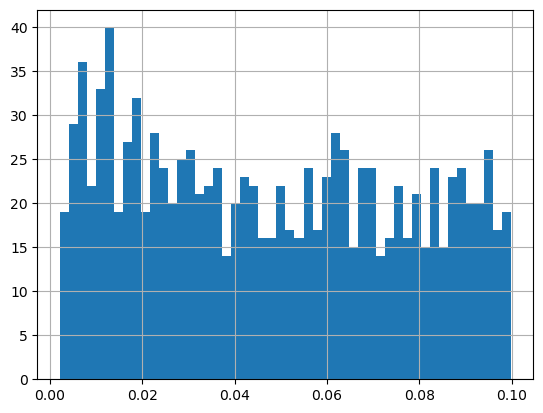

In [81]:
# Inspect values 
print(cv.sort_values().head(40))
cv[cv < 0.1].hist(bins=50)

## Full feature matrix assembly and QC summary

**QC scope:** deliberately distinct from per-family QC already completed at extraction - every family had already passed exact-match refactor validation and its own [0,1]/NaN checks. These checks targeted properties that only exist once the matrix is assembled, i.e. cannot be seen by any single family looking only at its own columns.

**Findings:**

1. **Row-wise missingness.** `full_df.isna().sum(axis=1)` is exactly 1 for all 160 subjects, entirely attributable to `preprocessing_error` (populated only on extraction failure; 0 failures occurred, so universally null by design). Confirms both that the check works as intended and that the matrix has no unexpected row-level incompleteness.

2. **Cross-family scale.** Band power sits on an unbounded positive scale (mean 75.5, range 15.9–286.4), while PLI/PLV/coherence/Kuramoto order/metastability are all bounded within or near [0,1] (family means 0.20–0.81). Confirmed via per-family `.describe()` on column means, not assumed. Not a defect - a property to account for at modelling time (scaling/normalisation).

3. **Exact-zero variance.** 0/5015 feature columns (identity/QC columns excluded via an explicit `feature_cols` list, defined once to keep this distinction consistent through modelling rather than re-derived ad hoc). No columns carry zero information.

4. **Near-zero variance (coefficient of variation).** All family means sit safely away from zero (min 0.15, band power; 0.65, Kuramoto order), so CV was computed directly across all 5015 feature columns as one pass rather than requiring per-family treatment. The distribution has a long right tail (max 2.42) but no gap near zero - confirmed via a zoomed histogram (CV < 0.1) showing continuous density, not two separable populations. The lowest 30 CV columns are exclusively PLV, exclusively spatially-adjacent electrode pairs (e.g. `Fz_FCz`, `C4_CP4`, `FC3_C3`). This corroborates, at full-cohort scale, the volume-conduction rationale previously only illustrated on a single pilot-subject pair (Decision 2: PLI chosen as primary connectivity measure because PLV/coherence inflate for adjacent electrodes). No columns were flagged or dropped — the effect is graded (falls off with electrode distance) rather than a binary contamination split, so exclusion, if any, is a modelling-stage decision, not a QC action.

**Residual assumptions / not yet checked:**
- Whether CV correlates directly with inter-electrode distance was not formally tested (visually consistent from the column names, not statistically confirmed).
- `bandpower_full_cohort.parquet`'s continued presence in the repo is now purely historical; not yet decided whether to remove it or retain it with a note.
- Matrix-level QC did not re-examine within-family plausibility (e.g. posterior/frontal alpha topography) - that was already covered at extraction and not repeated here.